In [39]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima, ARIMA
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,root_mean_squared_error, r2_score

In [12]:
df= joblib.load(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl')

In [13]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,lag6,lag12,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,rolling_mean12,rolling_std12
Month,,,,,,,,,,,,,,
1949-01-01,112,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,112.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-03-01,132,3,1,118.0,112.0,NaN,NaN,NaN,120.666667,10.263203,NaN,NaN,NaN,NaN
1949-04-01,129,4,2,132.0,118.0,112.0,NaN,NaN,126.333333,7.371115,NaN,NaN,NaN,NaN
1949-05-01,121,5,2,129.0,132.0,118.0,NaN,NaN,127.333333,5.686241,NaN,NaN,NaN,NaN


In [14]:
df= df.asfreq('MS')

In [15]:
df.isnull().sum()

#Passengers       26
month             26
quater            26
lag1              27
lag2              28
lag3              29
lag6              32
lag12             38
rolling_mean3     28
rolling_std3      28
rolling_mean6     31
rolling_std6      31
rolling_mean12    37
rolling_std12     37
dtype: int64

In [17]:
df.fillna(method='bfill', inplace=True)

C:\Users\MINE\AppData\Local\Temp\ipykernel_1104\3314729575.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


In [18]:
df.duplicated().sum()

np.int64(26)

In [19]:
df.drop_duplicates(keep='first', inplace=True)

In [20]:
df.shape

(118, 14)

In [21]:
df.head()

,#Passengers,month,quater,lag1,lag2,lag3,lag6,lag12,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,rolling_mean12,rolling_std12
Month,,,,,,,,,,,,,,
1949-01-01,112.0,1.0,1.0,112.0,112.0,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,124.583333,12.153999
1949-02-01,118.0,2.0,1.0,112.0,112.0,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,124.583333,12.153999
1949-03-01,132.0,3.0,1.0,118.0,112.0,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,124.583333,12.153999
1949-04-01,129.0,4.0,2.0,132.0,118.0,112.0,112.0,112.0,126.333333,7.371115,124.5,8.916277,124.583333,12.153999
1949-05-01,121.0,5.0,2.0,129.0,132.0,118.0,112.0,112.0,127.333333,5.686241,124.5,8.916277,124.583333,12.153999


In [31]:
train= df.iloc[:-24, :].asfreq('MS')
test= df.iloc[-24:, :].asfreq('MS')

In [32]:
arima= auto_arima(
  train['#Passengers'].ffill(),
  seasonal=False
)

In [33]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  115
Model:               SARIMAX(2, 1, 2)   Log Likelihood                -513.536
Date:                Fri, 07 Aug 2026   AIC                           1039.072
Time:                        21:58:04   BIC                           1055.489
Sample:                    01-01-1949   HQIC                          1045.734
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.6148      0.158      3.890      0.000       0.305       0.925
ar.L1          1.6384      0.057     28.505      0.000       1.526       1.751
ar.L2         -0.8849      0.049    -18.004      0.000      -0.981      -0.789
ma.L1         -1.7856      0.072    -24.960      0.000      -1.926      -1.645
ma.L2          0.8450      0.071     11.958      0.000       0.707       0.984
sigma2       465.2818     72.874      6.385      0.000     322.452     608.111
===================================================================================
Ljung-Box (L1) (Q):                   0.46   Jarque-Bera (JB):                 2.80
Prob(Q):                              0.50   Prob(JB):                         0.25
Heteroskedasticity (H):               4.98   Skew:                             0.38
Prob(H) (two-sided):                  0.00   Kurtosis:                         2.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [34]:
arima_forecast= arima.predict(len(test))

In [40]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions), 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')

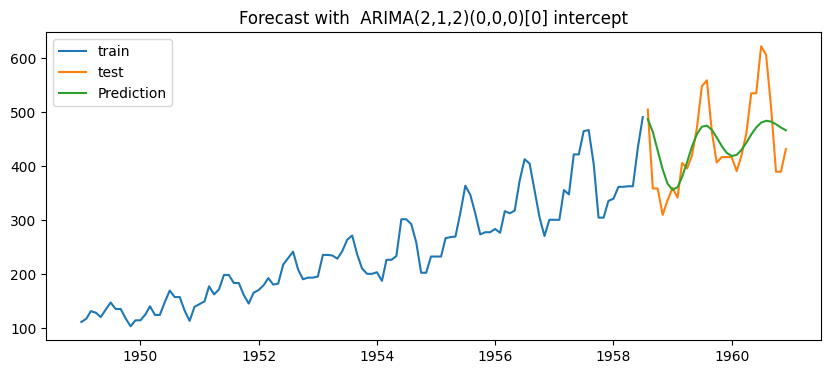

mean absolute error: 45.74
mean absolute percentage error: 10.0%
r2 score: 0.45
root mean squared error: 59.67


In [41]:
model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),arima_forecast, arima)

In [42]:
sarima= auto_arima(train['#Passengers'].ffill(),
                   seasonal=True,
                   stationary=True,
                   m=12)

In [45]:
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                        SARIMAX Results                                        
===============================================================================================
Dep. Variable:                                       y   No. Observations:                  115
Model:             SARIMAX(2, 0, 1)x(1, 0, [1, 2], 12)   Log Likelihood                -500.088
Date:                                 Fri, 07 Aug 2026   AIC                           1014.176
Time:                                         22:05:56   BIC                           1033.391
Sample:                                     01-01-1949   HQIC                          1021.975
                                          - 07-01-1958                                         
Covariance Type:                                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5644      0.168      9.311      0.000       1.235       1.894
ar.L2         -0.5656      0.166     -3.407      0.001      -0.891      -0.240
ma.L1         -0.8853      0.102     -8.680      0.000      -1.085      -0.685
ar.S.L12       0.9324      0.083     11.234      0.000       0.770       1.095
ma.S.L12      -0.6220      0.129     -4.840      0.000      -0.874      -0.370
ma.S.L24       0.2316      0.197      1.175      0.240      -0.155       0.618
sigma2       283.7835     25.475     11.140      0.000     233.853     333.714
===================================================================================
Ljung-Box (L1) (Q):                   0.25   Jarque-Bera (JB):                65.12
Prob(Q):                              0.62   Prob(JB):                         0.00
Heteroskedasticity (H):               8.52   Skew:                             0.21
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [46]:
sarima_pred= sarima.predict(len(test))

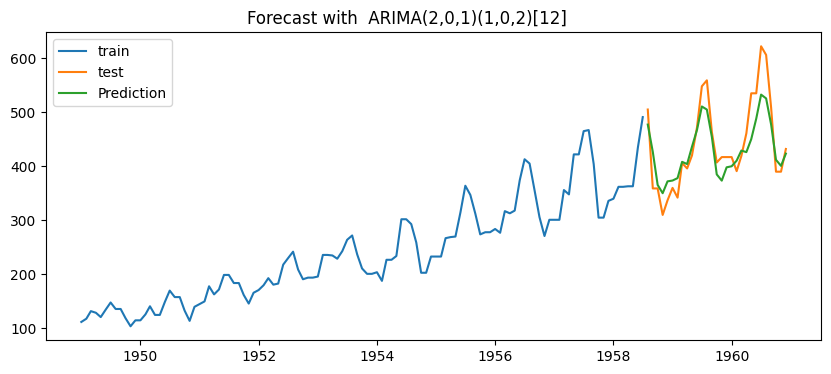

mean absolute error: 30.98
mean absolute percentage error: 7.000000000000001%
r2 score: 0.76
root mean squared error: 39.26


In [47]:
model_evaluator(train['#Passengers'].ffill(), test['#Passengers'].ffill(),sarima_pred, sarima)